In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
sentences = [
# Cricket
"The batsman hit a six over long on.",
"The bowler delivered a fast yorker.",
"The cricket team celebrated their victory.",
"The bowler took three wickets in one over.",

# Cooking
"I chopped onions and tomatoes for the curry.",
"The chef baked a chocolate cake.",
"Cooking pasta requires boiling water.",

# Cybersecurity
"Strong passwords help protect online accounts.",
"Cybersecurity prevents unauthorized system access.",
"Firewalls protect networks from cyber attacks."
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

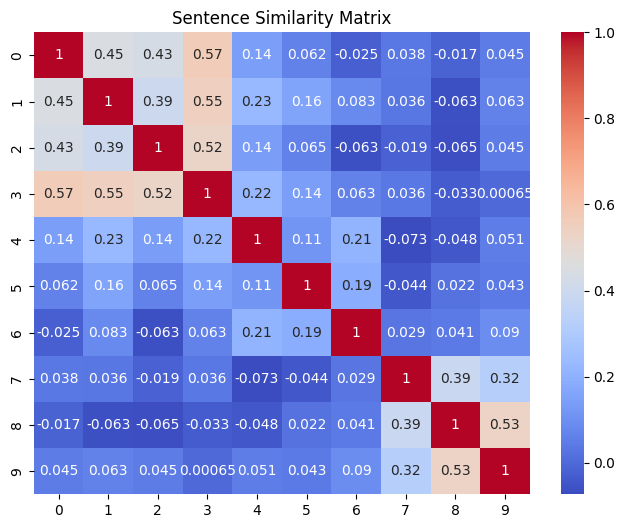

In [5]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Matrix")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

for i in top_indices:
    print(sentences[i], "-> similarity:", similarities[i])

The bowler took three wickets in one over. -> similarity: 0.9913637
The batsman hit a six over long on. -> similarity: 0.54933584
